# 1. Introdução

**Objetivo:** Validar requisitos do planejamento_inicial.md antes de Feature Engineering e modelagem.

✅ **Requisitos a validar:**
1. **user_id**: identificador único do usuário (quantidade, tipo)
2. **item_id**: identificador único do produto (quantidade, tipo)
3. **score ordinal**: distribuição dos eventos (view=1, addtocart=2, transaction=3)
4. **value**: valor monetário dos itens (property 790)
5. **Temporal**: viabilidade de split 60% treino / 20% validação / 20% teste

----

## Estrutura da análise

1. Validação básica (shape, nulls, duplicados)
2. Distribuição dos eventos (score ordinal)
3. Sparsity de usuários
4. Sparsity de produtos
5. Densidade da matriz usuário-item
6. Value monetário (property 790)
7. Temporal (janela de coleta)
8. Conclusões

---

# 2. Descrição do Dataset

O RetailRocket Ecommerce Dataset é composto por três arquivos complementares. Em conjunto, eles permitem reconstruir o contexto comportamental do usuário, as propriedades dos itens e a hierarquia de categorias do catálogo.

| Arquivo | Papel no projeto |
|---|---|
| `events.csv` | Registra as interações dos usuários com os itens |
| `item_properties_part1.csv` e `item_properties_part2.csv` | Guardam propriedades temporais dos itens |
| `category_tree.csv` | Descreve a hierarquia entre categorias |

A leitura correta dessas tabelas é fundamental porque o projeto não trabalha com feedback explícito. O sinal principal vem de ações de navegação e de compra, que precisam ser interpretadas como evidências graduais de interesse.

## events.csv

A tabela `events.csv` concentra o histórico comportamental dos visitantes e é a base central para a construção do sinal implícito do modelo. Cada linha representa uma interação entre um usuário e um item em um instante específico.

| Coluna | Significado |
|---|---|
| `timestamp` | Data e hora do evento em Unix timestamp, em milissegundos |
| `visitorid` | Identificador anônimo do visitante |
| `event` | Tipo de ação executada pelo usuário |
| `itemid` | Identificador do produto associado ao evento |
| `transactionid` | Identificador da compra, preenchido somente quando o evento é uma transação |

Os eventos possíveis são `view`, `addtocart` e `transaction`. Eles representam um funil natural de intenção: primeiro o usuário observa o item, depois pode demonstrar interesse adicionando ao carrinho e, por fim, eventualmente conclui a compra.

Como não existe nota explícita de preferência, este projeto trabalha com feedback implícito. Isso significa que o modelo não aprende “gostou” ou “não gostou” diretamente; ele infere interesse a partir da intensidade e da raridade dos comportamentos observados.

## item_properties.csv

A tabela `item_properties.csv` descreve as propriedades dos itens ao longo do tempo. Ela é temporal por natureza: o mesmo produto pode aparecer com valores diferentes para uma propriedade em instantes distintos.

| Coluna | Significado |
|---|---|
| `timestamp` | Momento em que a propriedade foi observada ou atualizada |
| `itemid` | Identificador do item |
| `property` | Nome da propriedade, que pode ser legível ou um código interno |
| `value` | Valor associado à propriedade naquele instante |

Nem toda propriedade é autoexplicativa. Algumas são reconhecíveis, como `categoryid` e `available`; outras aparecem como códigos internos do catálogo. Esta característica é relevante porque o EDA precisa separar atributos semanticamente úteis de variáveis que exigirão interpretação adicional ou engenharia de features.

A presença de timestamps neste arquivo indica que os atributos do item não são estáticos. Isso abre espaço para features temporais, como o estado mais recente do produto, o histórico de alterações e a possível variação de preço ao longo da janela observada.

## category_tree.csv

A tabela `category_tree.csv` representa a hierarquia do catálogo. Ela não traz o produto em si, mas a organização taxonômica das categorias, permitindo entender como itens se agrupam em níveis mais altos e mais específicos.

| Coluna | Significado |
|---|---|
| `categoryid` | Identificador da categoria |
| `parentid` | Identificador da categoria pai |

Esse tipo de estrutura é útil porque recomendadores não operam apenas no nível do item. Em muitos casos, a categoria ajuda a suavizar a esparsidade, a ampliar cobertura e a produzir generalizações mais robustas para itens pouco observados.

Em outras palavras, a árvore de categorias é uma fonte de contexto semântico. Ela será importante nas etapas de feature engineering e na análise de similaridade entre itens que pertencem ao mesmo ramo do catálogo.

---

# 3. Carregamento dos Dados

Nesta etapa, o objetivo é materializar localmente os arquivos do dataset e consolidar as fontes que serão usadas na análise. A união de `item_properties_part1.csv` e `item_properties_part2.csv` é necessária porque a base de atributos dos itens foi distribuída em dois arquivos complementares.

A estrutura final usada na análise é composta por três tabelas principais: `events`, `category_tree` e `item_properties`. A partir delas, o notebook passa a investigar volume, cobertura, sparsity, comportamento temporal e características do catálogo.

In [1]:
import os
import sys
from pathlib import Path
import shutil

import kagglesdk.kaggle_env as kaggle_env
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not hasattr(kaggle_env, "get_web_endpoint"):
    kaggle_env.get_web_endpoint = kaggle_env.get_endpoint

import kagglehub

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path(".").resolve()

repo_root = current_dir
while repo_root.name != "ecommerce-recsys-mlops" and repo_root != repo_root.parent:
    repo_root = repo_root.parent

if repo_root == repo_root.parent:
    repo_root = current_dir

raw_data_dir = repo_root / "data" / "raw"

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))



sns.set_theme(style="whitegrid")

required_files = [
    "events.csv",
    "category_tree.csv",
    "item_properties_part1.csv",
    "item_properties_part2.csv",
]

raw_data_dir.mkdir(parents=True, exist_ok=True)

missing_files = [
    filename
    for filename in required_files
    if not (raw_data_dir / filename).exists()
]

if missing_files:
    print("Arquivos ausentes encontrados:")
    for filename in missing_files:
        print(f" - {filename}")

    print("\nBaixando dataset do Kaggle...")

    cache_path = Path(
        kagglehub.dataset_download(
            "retailrocket/ecommerce-dataset"
        )
    )

    print("\nOrganizando arquivos no repositório local...")

    for arquivo in cache_path.iterdir():
        if arquivo.is_file():
            destino_final = raw_data_dir / arquivo.name

            if not destino_final.exists():
                shutil.copy2(arquivo, destino_final)
                print(f"Arquivo adicionado: {arquivo.name}")
            else:
                print(f"Arquivo já existe na pasta local: {arquivo.name}")

else:
    print("Todos os arquivos necessários já existem localmente.")
    print("Download pulado.")

print(f"\nArquivos prontos em: {raw_data_dir}")
for filename in sorted(os.listdir(raw_data_dir)):
    print(f" - {filename}")

Arquivos ausentes encontrados:
 - events.csv
 - category_tree.csv
 - item_properties_part1.csv
 - item_properties_part2.csv

Baixando dataset do Kaggle...


100%|██████████| 291M/291M [00:10<00:00, 28.0MB/s] 

Extracting files...



Organizando arquivos no repositório local...
Arquivo adicionado: category_tree.csv
Arquivo adicionado: events.csv
Arquivo adicionado: item_properties_part1.csv
Arquivo adicionado: item_properties_part2.csv

Arquivos prontos em: C:\Users\Patrick\Desktop\FIAP\Tech Challenge 2\ecommerce-recsys-mlops\data\raw
 - .gitkeep
 - category_tree.csv
 - events.csv
 - item_properties_part1.csv
 - item_properties_part2.csv


## Leitura e organização dos arquivos

O primeiro bloco operacional baixa o dataset e organiza os arquivos dentro de `data/raw`. Isso é importante porque o notebook deixa de depender de um cache externo efêmero e passa a trabalhar com uma estrutura local e reprodutível, alinhada com a organização do projeto.

Para a análise, o ponto mais relevante é que a tabela de propriedades dos itens é consolidada a partir de duas partes físicas, mas semanticamente ela continua sendo uma única fonte de atributos. A partir daqui, as leituras passam a usar os arquivos já materializados no repositório, o que simplifica a rastreabilidade das próximas etapas do pipeline.

In [2]:
events = pd.read_csv(raw_data_dir / "events.csv")

category_tree = pd.read_csv(
    raw_data_dir / "category_tree.csv"
)

item_properties_1 = pd.read_csv(
    raw_data_dir / "item_properties_part1.csv"
)

item_properties_2 = pd.read_csv(
    raw_data_dir / "item_properties_part2.csv"
)

item_properties = pd.concat(
    [item_properties_1, item_properties_2],
    ignore_index=True
)

---

# 4. Visão Geral do Dataset

As saídas de `shape`, `info()` e `describe()` dão a primeira visão operacional da base. Elas confirmam o volume do problema, o tipo das variáveis e a distribuição básica das colunas observadas.

O dataset de eventos possui 2.756.101 interações, 140.758 usuários únicos e 235.061 produtos únicos. Em um sistema de recomendação, esse é um cenário clássico de matriz usuário-item extremamente esparsa: há muito mais combinações possíveis do que interações observadas.

Essa escala muda o desenho do modelo. Ela favorece abordagens que lidam bem com feedback implícito, amostragem negativa, regularização forte e estratégias de generalização que consigam aprender padrões mesmo quando cada usuário interage com poucos itens.

In [3]:
print(f"Shape Events: ",events.shape)
print(f"Shape Category: ",category_tree.shape)
print(f"Shape Item Properties: ",item_properties.shape)

# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
display(events.info())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
display(events.describe(include='all'))

print("\n=== VALORES UNICOS Events ===\n")
resumo_colunas = pd.DataFrame({
    'valores únicos': events.nunique(dropna=False),
    'Total de Linhas': len(events),
    'É 100% Única?': events.nunique(dropna=False) == len(events)
})
display(resumo_colunas)

print("\n=== VALORES UNICOS item_properties ===\n")
resumo_colunas_properties = pd.DataFrame({
    'Valores Únicos': item_properties.nunique(dropna=False),
    'Total de Linhas': len(item_properties),
    'É 100% Única?': item_properties.nunique(dropna=False) == len(item_properties)
})
display(resumo_colunas_properties)


Shape Events:  (2756101, 5)
Shape Category:  (1669, 2)
Shape Item Properties:  (20275902, 4)
=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None


=== ESTATÍSTICAS DESCRITIVAS ===



,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000



=== VALORES UNICOS Events ===



,valores únicos,Total de Linhas,É 100% Única?
timestamp,2750455,2756101,False
visitorid,1407580,2756101,False
event,3,2756101,False
itemid,235061,2756101,False
transactionid,17673,2756101,False



=== VALORES UNICOS item_properties ===



,Valores Únicos,Total de Linhas,É 100% Única?
timestamp,18,20275902,False
itemid,417053,20275902,False
property,1104,20275902,False
value,1966868,20275902,False


---

## 5. Qualidade dos Dados

A inspeção de valores nulos e duplicados existe para responder uma pergunta simples: o que é ausência legítima de informação e o que é problema de captura ou integração?

Neste dataset, `transactionid` nulo é esperado na maioria dos eventos, porque somente interações de compra recebem esse identificador. Já a presença de poucos duplicados precisa ser medida com atenção, pois pode indicar repetição operacional, mas também pode refletir a natureza de eventos gerados em sequência pelo usuário. Em ambos os casos, o impacto é direto no pipeline: a base precisa ser limpa antes da criação do score implícito e do split temporal.

In [4]:
print(events.isnull().sum())
print(events.duplicated().sum())

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64
460


In [5]:
events = events.drop_duplicates()
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


---

## 6. Distribuição dos Eventos

A distribuição dos eventos mostra como a atenção dos usuários se divide entre explorar itens, adicioná-los ao carrinho e finalizar compras. Essa leitura é central para entender o desbalanceamento natural do problema.

Os resultados observados indicam aproximadamente 96,7% de `view`, 2,5% de `addtocart` e 0,8% de `transaction`. Isso significa que, se o modelo fosse treinado apenas com transações, ele perderia a maior parte do sinal comportamental disponível e aprenderia com um conjunto de respostas muito pequeno.

Por isso, a estratégia do projeto é transformar os três eventos em um score ordinal de feedback implícito, com `view = 1`, `addtocart = 2` e `transaction = 3`. Essa escolha preserva informação de intenção e permite que o modelo aprenda gradações de interesse, e não apenas compras concluídas.


### Impacto no projeto
- Feature Engineering: eventos precisam ser ponderados de forma ordinal.
- Popularity Recommender: continua sendo um baseline necessário.
- SVD: aprende melhor quando o comportamento é transformado em score.
- MLP: precisa lidar com classes implícitas desequilibradas.
- Split temporal: mantém a distribuição original dos eventos no tempo.
- Métricas: precisão isolada de compra não captura todo o funil.

In [6]:
events["event"].value_counts(
    normalize=True
).mul(100)

event
view           96.682333
addtocart       2.502721
transaction     0.814947
Name: proportion, dtype: float64

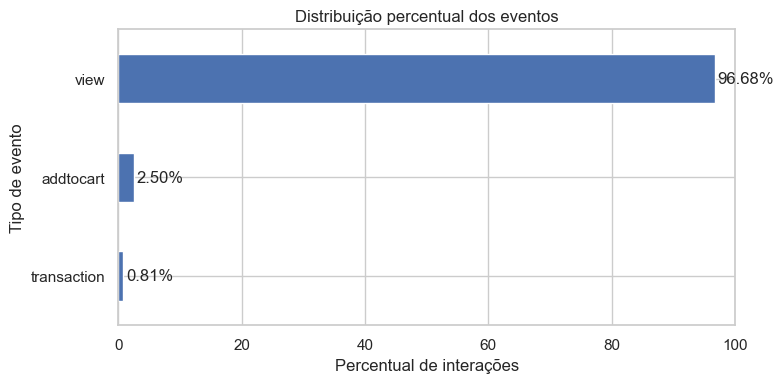

In [7]:
event_distribution = (
    events["event"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))

event_distribution.plot(
    kind="barh",
    ax=ax
)

for i, value in enumerate(event_distribution):
    ax.text(
        value + 0.5,
        i,
        f"{value:.2f}%",
        va="center"
    )

ax.set_title("Distribuição percentual dos eventos")
ax.set_xlabel("Percentual de interações")
ax.set_ylabel("Tipo de evento")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

---

## 7. Análise dos Usuários

Depois da limpeza básica, a análise por usuário responde a duas perguntas: quantas interações cada visitante gera e quão concentrado ou disperso esse comportamento está na base.

Essa etapa existe porque sistemas de recomendação aprendem com histórico. Se cada usuário aparece poucas vezes, o modelo precisa generalizar com pouquíssimos exemplos por perfil. É exatamente nesse ponto que surge o conceito de `User Sparsity`: a maior parte dos usuários interage com uma fração mínima do catálogo e oferece pouca evidência direta para inferência individual.

In [8]:
user_interactions = (
    events
    .groupby("visitorid")
    .size()
    .sort_values(ascending=False)
)
user_interactions.describe()

count    1.407580e+06
mean     1.957715e+00
std      1.257981e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

## Distribuição de interações por usuário

### O que estamos analisando?
- Quantas interações cada usuário gerou no período observado.
- Como o histórico de navegação se espalha entre perfis muito ativos e perfis quase sem dados.

### Por que isso é importante?
- Isso mostra o nível de `User Sparsity` da base.
- Quando a maioria dos usuários interage poucas vezes, o modelo precisa generalizar com pouco contexto.

### O que os resultados mostram?
- A mediana é de 1 interação por usuário.
- A grande maioria dos usuários tem histórico muito curto.

### Impacto no projeto
- Feature Engineering: ajuda a priorizar sinais agregados e temporais.
- Popularity Recommender: tende a funcionar como baseline forte nesse cenário.
- SVD: precisa de regularização para não superajustar usuários raros.
- MLP: depende de embeddings bem regularizados e amostragem adequada.
- Split temporal: evita treinar com perfis que ainda não existiam no passado.
- Métricas: recomendações para usuários frios precisam ser avaliadas separadamente.

## Leitura da sparsity de usuários

A mediana de uma interação por usuário confirma que o comportamento é fortemente esparso. Além disso, cerca de 96% dos usuários possuem até cinco interações, o que mostra que a maior parte da base oferece histórico muito curto.

Do ponto de vista de recomendação, isso afeta diretamente a capacidade do modelo de aprender perfis personalizados. Em bases assim, abordagens puramente user-based tendem a sofrer mais, enquanto estratégias que exploram similaridade entre itens, fatores latentes e sinais agregados de comportamento costumam ter melhor robustez.

In [9]:
user_interactions.quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25     1.0
0.50     1.0
0.75     2.0
0.90     3.0
0.95     5.0
0.99    13.0
dtype: float64

O cálculo `(user_interactions <= 5).sum()` conta quantos usuários possuem no máximo 5 eventos registrados.

In [10]:
(user_interactions <= 5).sum()

np.int64(1348953)

---

## 8. Análise dos Compradores

Nesta etapa o recorte passa a considerar apenas os eventos de `transaction`. O objetivo é medir quantos usuários chegam efetivamente à compra e quantas vezes compram dentro da janela observada.

Essa leitura é importante porque compra é o sinal mais forte do funil, mas também o mais raro. Se eu treinar um modelo somente com transações, eu ganho precisão no rótulo e perco quase todo o contexto comportamental anterior, que é justamente o que ajuda o sistema a generalizar para usuários novos ou pouco ativos.

In [11]:
transactions = events[
    events["event"] == "transaction"
]

## Leitura do perfil de compra

Apenas 11.719 usuários realizaram transações, e a maioria deles comprou apenas uma vez no período analisado. Isso mostra que o comportamento de compra é ainda mais concentrado do que o comportamento geral de navegação.

Para o modelo, isso significa que a transação isolada é um sinal valioso, mas insuficiente sozinha. A combinação com visualizações e adições ao carrinho é o que permite reconstruir intenção, reduzir perda de contexto e produzir recomendações mais úteis em cenários de feedback implícito.

In [12]:
transactions_per_user = (
    transactions
    .groupby("visitorid")
    .size()
)

buyers_summary = pd.DataFrame({
    "Métrica": [
        "Compradores",
        "Até 5 compras"
    ],
    "Valor": [
        transactions_per_user.shape[0],
        (transactions_per_user <= 5).sum()
    ]
})

display(buyers_summary)

display(
    transactions_per_user.describe()
)

display(
    transactions_per_user.quantile(
        [0.25,0.5,0.75,0.9,0.95,0.99]
    )
)

,Métrica,Valor
0,Compradores,11719
1,Até 5 compras,11425


count    11719.000000
mean         1.916290
std          8.850529
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        559.000000
dtype: float64

0.25     1.0
0.50     1.0
0.75     1.0
0.90     2.0
0.95     4.0
0.99    13.0
dtype: float64

---

## 9. Análise dos Produtos

A leitura por item mostra como as interações se distribuem pelo catálogo. Essa análise é necessária para identificar popularidade, concentração e efeito de cauda longa, que são determinantes para qualquer abordagem de recomendação.

Quando poucos itens concentram grande parte das interações, o sistema tende a recomendar o que já é popular. Quando a cauda longa é muito extensa, o desafio passa a ser evitar que itens pouco vistos desapareçam do ranking sem uma estratégia de generalização.

In [13]:
item_interactions = (
    events
    .groupby("itemid")
    .size()
)

item_interactions.describe()

count    235061.000000
mean         11.723089
std          37.024810
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64

## Leitura da distribuição por item

Cerca de 65,8% dos produtos possuem até cinco interações, o que confirma uma cauda longa relevante no catálogo. Em termos práticos, grande parte dos itens aparece pouco no histórico e, por isso, depende de sinais auxiliares para ganhar visibilidade no modelo.

Essa distribuição impacta diretamente três famílias de abordagem: recomendadores de popularidade tendem a amplificar o topo da distribuição; modelos matriciais como SVD precisam de regularização e suporte suficiente para aprender fatores estáveis; e modelos neurais baseados em embeddings precisam de cuidado extra com itens raros para não superajustar o catálogo mais popular.

In [14]:
item_interactions.quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25      1.0
0.50      3.0
0.75      9.0
0.90     25.0
0.95     47.0
0.99    143.0
dtype: float64

In [15]:
(item_interactions <= 5).sum()

np.int64(154767)

## Densidade da matriz usuário-item

Esta análise mede o quanto a matriz usuário-item está preenchida.

Em recomendação, isso é essencial porque a maior parte das combinações possíveis entre usuários e produtos nunca acontece na prática.

A densidade da matriz usuário-item foi calculada como:

densidade = interações usuário-item observadas / combinações usuário-item possíveis

sparsity = 1 - densidade

Quanto mais próximo de 1, mais vazia é a matriz.

In [16]:
num_users = events["visitorid"].nunique()
num_items = events["itemid"].nunique()
num_observed_interactions = (
    events[["visitorid", "itemid"]]
    .drop_duplicates()
    .shape[0]
)

possible_interactions = num_users * num_items

matrix_density = num_observed_interactions / possible_interactions
matrix_sparsity = 1 - matrix_density

sparsity_summary = pd.DataFrame({
    "metric": [
        "Usuários únicos",
        "Itens únicos",
        "Interações usuário-item observadas",
        "Combinações usuário-item possíveis",
        "Densidade da matriz",
        "Sparsity da matriz"
    ],
    "value": [
        num_users,
        num_items,
        num_observed_interactions,
        possible_interactions,
        matrix_density,
        matrix_sparsity
    ]
})

display(sparsity_summary)

,metric,value
0,Usuários únicos,1.407580e+06
1,Itens únicos,2.350610e+05
2,Interações usuário-item observadas,2.145179e+06
3,Combinações usuário-item possíveis,3.308672e+11
4,Densidade da matriz,6.483505e-06
5,Sparsity da matriz,9.999935e-01


## Distribuição de interações por produto

### O que estamos analisando?
- Quantas interações cada item recebeu no período.
- Como a atenção do catálogo se concentra em poucos produtos.

### Por que isso é importante?
- Isso evidencia a `Long Tail` do catálogo.
- Itens raros precisam de suporte de features de conteúdo e categoria.

### O que os resultados mostram?
- Grande parte dos produtos tem poucas interações.
- O catálogo não se comporta de forma uniforme: poucos itens concentram muita atenção.

### Impacto no projeto
- Feature Engineering: categoria e preço ganham mais peso para itens frios.
- Popularity Recommender: tende a favorecer itens já muito visíveis.
- SVD: precisa tratar a cauda longa com regularização.
- MLP: embeddings de itens raros podem ficar instáveis.
- Split temporal: itens novos devem entrar no teste sem contaminar o treino.
- Métricas: é importante medir desempenho também na cauda longa.

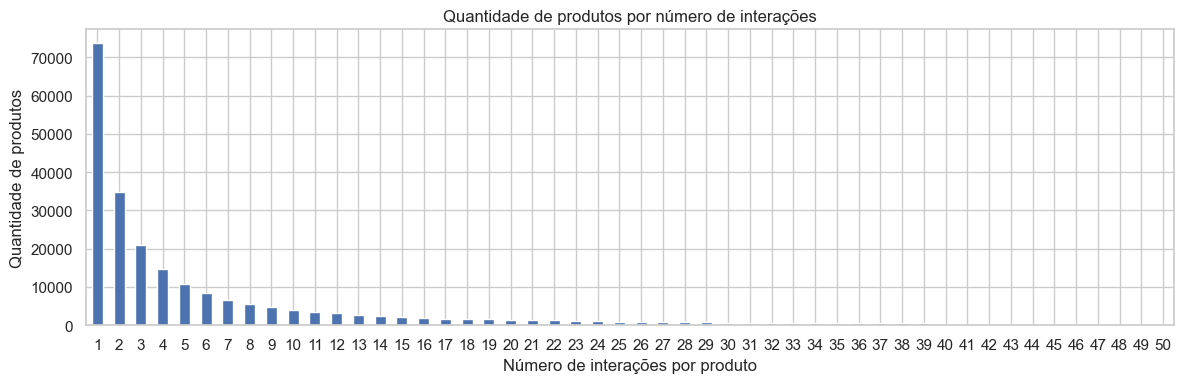

In [17]:
item_interaction_frequency = (
    item_interactions
    .value_counts()
    .sort_index()
)

item_interaction_frequency_limited = item_interaction_frequency.loc[
    item_interaction_frequency.index <= 50
]

fig, ax = plt.subplots(figsize=(12, 4))

item_interaction_frequency_limited.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Quantidade de produtos por número de interações")
ax.set_xlabel("Número de interações por produto")
ax.set_ylabel("Quantidade de produtos")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

## Sparsity da Matriz Usuário-Item

### O que estamos analisando?

Queremos medir o quanto a matriz usuário-item está preenchida.

Em sistemas de recomendação, a maioria das combinações possíveis entre usuários e produtos nunca ocorre na prática, porque um usuário normalmente interage com poucos produtos em comparação com o tamanho total do catálogo.

Em sistemas de recomendação, normalmente representamos os dados como uma matriz **usuário × item**.

Nessa matriz:

- cada linha representa um usuário;
- cada coluna representa um produto;
- cada célula representa se aquele usuário interagiu ou não com aquele produto.

### Por que isso é importante?

Quanto mais esparsa for a matriz:

- mais difícil fica aprender preferências
- maior tende a ser o problema de cold start
- mais importante se torna utilizar feedback implícito

### Onde vieram os valores aproximados
Analisamos primeiro a atividade dos usuários `user_interactions` foi criada agrupando os eventos por usuário, depois calculamos quantos usuários possuem no máximo 5 interações.

Com resultado:
- 134.895 usuários possuem até 5 interações
- 140.758 usuários existem no total

Calculamos a proporção: 134.895 / 140.758 ≈ 0,958 
- 95,8% dos usuários possuem até 5 interações.

Fizemos a mesma coisa para `item_interactions` calculando quantos eventos cada produto recebeu no dataset.

Com resultado:
- 154.767 produtos possuem até 5 interações
- 235.061 produtos existem no total

Calculamos a proporção: 154.767 / 235.061 ≈ 0,658
- 65,8% dos produtos possuem até 5 interações

### Cálculo da densidade da matriz
A densidade mede quanto da matriz está preenchido com interações reais.

Onde a formula é: 
- combinações possíveis = número de usuários únicos × número de produtos únicos

Então:
- combinações possíveis = 140.758 × 235.061

Gerando aproximadamento 33 bilhões de combinações usuário-produto possíveis, mas o dataset possui apenas uma pequena fração dessas combinações registradas como interação real.

Por isso calculamos também `sparsity = 1 - densidade` quanto mais a sparsity se aproxima de 1, mais vazia é a matriz.

### O que os resultados mostram?

Os resultados indicam três pontos importantes:

- A maioria dos usuários possui pouquíssimas interações.
- A maioria dos produtos também possui poucas interações.
- A matriz usuário-item é extremamente esparsa.

Isso mostra que o modelo terá pouca informação direta sobre muitas combinações de usuários e produtos.

### Impacto no projeto

Como as interações de compra são raras e o histórico dos usuários é pequeno, utilizar apenas transaction como sinal de treino reduziria muito a quantidade de informação disponível.

Por isso, faz sentido trabalhar com feedback implícito, usando diferentes pesos para os eventos:

- view = 1
- addtocart = 2
- transaction = 3

Essa estratégia permite que o modelo aprenda não apenas a partir de compras, mas também a partir de sinais mais fracos de interesse, como visualizações e adições ao carrinho.

Além disso, a alta sparsity justifica o uso de modelos próprios para recomendação, como:

- Popularity Recommender, como baseline simples;
- SVD, para fatoração da matriz usuário-item;
- MLP com embeddings, para aprender representações de usuários e produtos mesmo em um cenário esparso.

---

## 10. Análise Temporal

O timestamp original está em Unix time, então ele precisa ser convertido para `datetime` antes de qualquer leitura temporal. Esse passo não é apenas técnico: ele permite localizar a janela de coleta, identificar variações ao longo dos dias e avaliar se o final da série está completo.

Em problemas de recomendação, a dimensão temporal é crítica. Ela influencia a criação do split de treino e teste, a interpretação de sazonalidade e a decisão sobre como lidar com eventos recentes versus históricos antigos.

In [18]:
events["datetime"] = pd.to_datetime(
    events["timestamp"],
    unit="ms"
)

events["date"] = events["datetime"].dt.date

temporal_summary = pd.DataFrame({
    "Métrica": [
        "Data Inicial",
        "Data Final"
    ],
    "Valor": [
        events["datetime"].min(),
        events["datetime"].max()
    ]
})

display(temporal_summary)

,Métrica,Valor
0,Data Inicial,2015-05-03 03:00:04.384
1,Data Final,2015-09-18 02:59:47.788


## Sazonalidade semanal

### O que estamos analisando?
- O volume de eventos ao longo dos dias da semana.

### Por que isso é importante?
- Ajuda a entender se o comportamento muda entre dias úteis e fim de semana.
- Isso afeta a estratégia temporal de treino e validação.

### O que os resultados mostraram?
- O padrão semanal não é uniforme.
- Há dias com maior concentração de interações e outros com queda natural de atividade.

### Impacto no projeto
- Feature Engineering: permite criar feature de dia da semana.
- Popularity Recommender: pode ser usado por janela temporal.
- SVD: se beneficia de segmentação temporal bem feita.
- MLP: pode aprender sinais de contexto temporal.
- Split temporal: evita misturar padrões de dias com comportamentos diferentes.
- Métricas: melhora a leitura por janela de tempo.

In [19]:
events["weekday"] = events["datetime"].dt.day_name()
events.groupby("weekday").size()

weekday
Friday       379624
Monday       439738
Saturday     305167
Sunday       334375
Thursday     418672
Tuesday      447006
Wednesday    431059
dtype: int64

In [20]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

(
    events
    .groupby("weekday")
    .size()
    .reindex(weekday_order)
)

weekday
Monday       439738
Tuesday      447006
Wednesday    431059
Thursday     418672
Friday       379624
Saturday     305167
Sunday       334375
dtype: int64

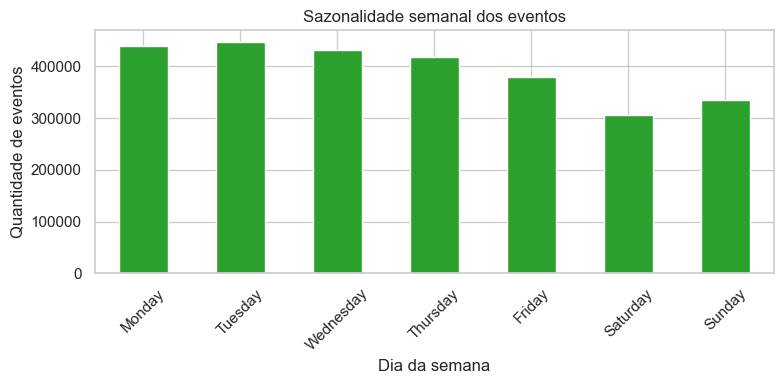

In [21]:
weekday_counts = events.groupby("weekday").size().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 4))
weekday_counts.plot(kind="bar", ax=ax, color="#2ca02c")
ax.set_title("Sazonalidade semanal dos eventos")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Quantidade de eventos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Evolução temporal dos eventos

### O que estamos analisando?
- Como `view`, `addtocart` e `transaction` evoluem ao longo do tempo.

### Por que isso é importante?
- Ajuda a verificar estabilidade do comportamento.
- Mostra se algum evento cresce ou cai de forma anormal.

### O que os resultados mostraram?
- O comportamento é relativamente estável ao longo da janela.
- Os três eventos seguem movimentos parecidos, mas com escalas diferentes.
- A queda final da série merece atenção porque pode indicar coleta incompleta.

### Impacto no projeto
- Feature Engineering: permite usar tendências por janela temporal.
- Popularity Recommender: pode ser recalibrado por período.
- SVD: precisa respeitar a ordem temporal dos eventos.
- MLP: pode incorporar sinais de recência.
- Split temporal: deve refletir a evolução real da base.
- Métricas: evita avaliações otimistas por vazamento temporal.

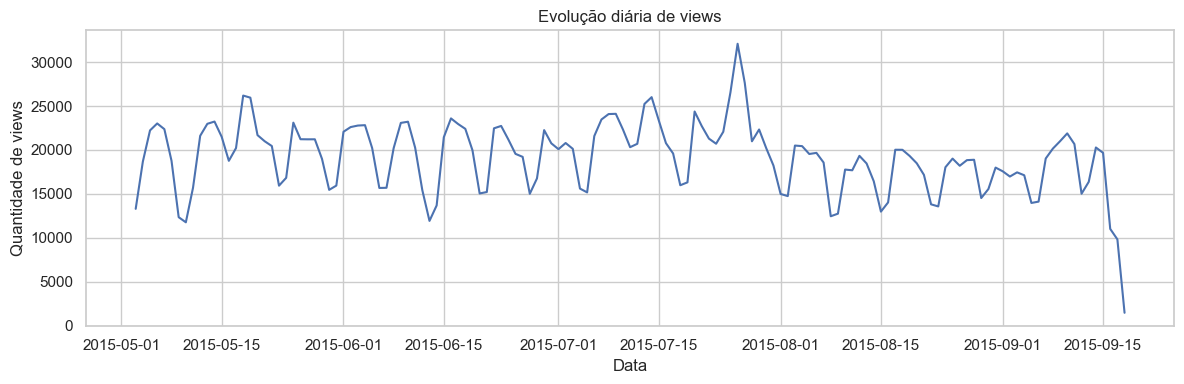

In [22]:
events_by_date_event = (
    events
    .groupby(["date", "event"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))

events_by_date_event["view"].plot(ax=ax)

ax.set_title("Evolução diária de views")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade de views")

plt.tight_layout()
plt.show()

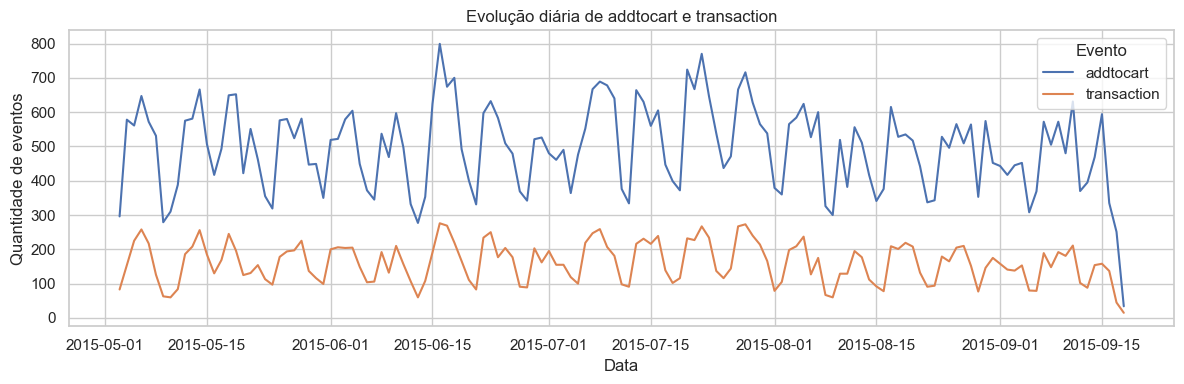

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))

events_by_date_event[["addtocart", "transaction"]].plot(ax=ax)

ax.set_title("Evolução diária de addtocart e transaction")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade de eventos")
ax.legend(title="Evento")

plt.tight_layout()
plt.show()

## Volume diário de eventos

A janela observada cobre de 2015-05-03 a 2015-09-18, ou seja, pouco mais de quatro meses de comportamento. O gráfico diário indica oscilação clara de volume e uma queda acentuada nos últimos dias da série, com o último ponto muito abaixo da média recente.

Esse padrão é um alerta importante. Pode haver coleta incompleta no fim do período ou simplesmente um recorte temporal encerrado antes da estabilização. Para o projeto, isso reforça a necessidade de split temporal consistente, evitando misturar eventos do futuro com o passado durante o treinamento.

In [24]:
events_by_date_event.tail(15)

event,addtocart,transaction,view
date,,,
2015-09-04,452,153,17124
2015-09-05,308,80,13973
2015-09-06,369,79,14124
2015-09-07,572,189,19030
2015-09-08,505,148,20158
2015-09-09,572,192,20995
2015-09-10,480,181,21887
2015-09-11,631,211,20671
2015-09-12,370,102,15023


### Conclusão

O comportamento apresenta estabilidade ao longo do período analisado.

Existe sazonalidade semanal clara e indícios de coleta incompleta nos últimos dias do dataset.

Esses resultados reforçam a utilização de um split temporal para avaliação dos modelos.

---

## 11. Produtos Mais Populares

A análise de produtos mais populares separa três visões do catálogo: itens mais visualizados, itens mais adicionados ao carrinho e itens mais comprados. Essa diferença é importante porque popularidade em navegação não equivale necessariamente a performance comercial.

Do ponto de vista de negócio, esta etapa ajuda a identificar produtos de atração, produtos de consideração e produtos de conversão. Do ponto de vista de modelagem, ela produz um baseline simples e também serve de referência para comparar o comportamento do recomendador com o comportamento histórico da base.

In [25]:
top_view = (
    events[events["event"] == "view"]
    .groupby("itemid")
    .size()
    .sort_values(ascending=False)
)
top_view.head(20)

itemid
187946    3410
461686    2538
5411      2325
370653    1854
219512    1740
298009    1642
96924     1633
309778    1565
257040    1531
384302    1528
335975    1428
111530    1397
441668    1389
7943      1346
320130    1333
151444    1230
234255    1214
190000    1164
142466    1135
37029     1131
dtype: int64

In [26]:
top_cart = (
    events[events["event"] == "addtocart"]
    .groupby("itemid")
    .size()
    .sort_values(ascending=False)
)
top_cart.head(20)

itemid
461686    304
312728    161
409804    152
320130    141
29196     135
7943       97
48030      95
441852     90
257040     89
445351     89
316753     84
369447     80
234255     77
17478      72
46232      72
37029      71
9877       70
158666     68
384302     65
279457     63
dtype: int64

In [27]:
top_transactions = (
    events[events["event"] == "transaction"]
    .groupby("itemid")
    .size()
    .sort_values(ascending=False)
)

top_transactions.head(20)

itemid
461686    133
119736     97
213834     92
7943       46
312728     46
445351     45
48030      41
248455     38
420960     38
17478      37
409804     35
320130     33
416017     32
46156      31
369447     31
268883     29
334401     28
257040     27
441852     27
37029      25
dtype: int64

## Leitura de popularidade

O produto mais visto não necessariamente é o mais comprado. Essa é uma distinção estrutural do funil: um item pode chamar atenção, gerar comparação e ainda assim não converter no mesmo ritmo que outros produtos do catálogo.

Para o negócio, essa diferença é valiosa porque mostra que o sistema precisa aprender mais do que contagem bruta de acessos. Para a modelagem, isso reforça a necessidade de combinar sinais de visibilidade, interesse intermediário e compra finalizada em um único score implícito, em vez de usar apenas popularidade de visualização.

### Leitura dos tops

- Os itens mais vistos, mais adicionados ao carrinho e mais comprados não são necessariamente os mesmos.
- Isso mostra que existe diferença entre atenção, intenção e conversão.
- O gráfico ajuda a comparar exposição com resultado final, evitando interpretar visualização como venda.

### Impacto no projeto
- Feature Engineering: apoia a criação de features de popularidade por evento.
- Popularity Recommender: serve como baseline direto para ranking.
- SVD: ajuda a identificar itens com forte sinal latente.
- MLP: permite comparar embeddings com comportamento histórico.
- Split temporal: os tops precisam ser recalculados por janela.
- Métricas: facilita validar se o modelo realmente supera um ranking simples.

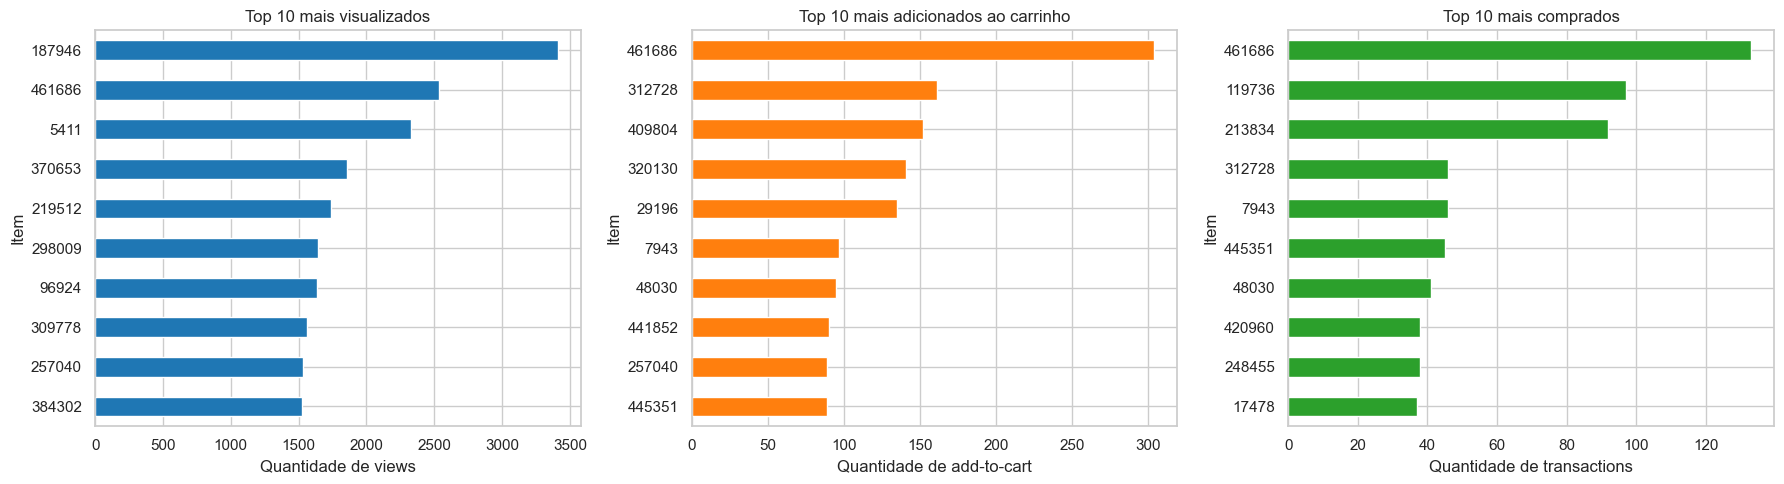

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_view.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#1f77b4")
axes[0].set_title("Top 10 mais visualizados")
axes[0].set_xlabel("Quantidade de views")
axes[0].set_ylabel("Item")

top_cart.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Top 10 mais adicionados ao carrinho")
axes[1].set_xlabel("Quantidade de add-to-cart")
axes[1].set_ylabel("Item")

top_transactions.head(10).sort_values().plot(kind="barh", ax=axes[2], color="#2ca02c")
axes[2].set_title("Top 10 mais comprados")
axes[2].set_xlabel("Quantidade de transactions")
axes[2].set_ylabel("Item")

plt.tight_layout()
plt.show()

---

## 12. Funil de Conversão dos Produtos

A tabela de funil cruza views, add-to-cart e transações por item. Ela existe para revelar onde cada produto perde ou ganha força ao longo da jornada e para comparar o comportamento dos itens que mais atraem atenção.

Essa análise é especialmente útil porque o score do modelo não deve depender apenas de volume absoluto. Um item com muitas views e baixa conversão pode indicar curiosidade sem intenção real; outro com menos exposição e conversão alta pode sinalizar forte aderência ao perfil do usuário.

In [29]:
transactions = (
    events[events["event"] == "transaction"]
    .groupby("itemid")
    .size()
)

views = (
    events[events["event"] == "view"]
    .groupby("itemid")
    .size()
)

conversion = (
    transactions
    .div(views)
    .fillna(0)
    .sort_values(ascending=False)
)

In [30]:
top_20_views = top_view.head(20).index

funil = pd.DataFrame({
    "views": (
        events[events["event"] == "view"]
        .groupby("itemid")
        .size()
    ),
    "addtocart": (
        events[events["event"] == "addtocart"]
        .groupby("itemid")
        .size()
    ),
    "transactions": (
        events[events["event"] == "transaction"]
        .groupby("itemid")
        .size()
    )
}).fillna(0)

funil.loc[top_20_views]

,views,addtocart,transactions
itemid,,,
187946,3410.0,2.0,0.0
461686,2538.0,304.0,133.0
5411,2325.0,9.0,0.0
370653,1854.0,0.0,0.0
219512,1740.0,48.0,12.0
298009,1642.0,0.0,0.0
96924,1633.0,0.0,0.0
309778,1565.0,48.0,15.0
257040,1531.0,89.0,27.0


As taxas do funil foram calculadas como:

View → AddToCart = total de addtocart / total de views

View → Transaction = total de transactions / total de views

AddToCart → Transaction = total de transactions / total de addtocart

In [31]:
event_counts = events["event"].value_counts()

views_total = event_counts.get("view", 0)
cart_total = event_counts.get("addtocart", 0)
transactions_total = event_counts.get("transaction", 0)

funnel_summary = pd.DataFrame({
    "stage": [
        "View",
        "AddToCart",
        "Transaction"
    ],
    "total_events": [
        views_total,
        cart_total,
        transactions_total
    ],
    "conversion_from_view": [
        1.0,
        cart_total / views_total,
        transactions_total / views_total
    ]
})

funnel_summary["conversion_from_view_pct"] = (
    funnel_summary["conversion_from_view"]
    .mul(100)
)

display(funnel_summary)

,stage,total_events,conversion_from_view,conversion_from_view_pct
0,View,2664218,1.000000,100.000000
1,AddToCart,68966,0.025886,2.588602
2,Transaction,22457,0.008429,0.842912


### Leitura do funil

- O volume cai a cada etapa do funil, como esperado.
- A conversão de `view` para `addtocart` e de `addtocart` para `transaction` ajuda a enxergar quais itens avançam no interesse do usuário.
- O funil agregado é útil para comparar produtos com muita exposição e pouca compra com produtos menos expostos, mas mais eficientes na conversão.

### Impacto no projeto
- Feature Engineering: permite criar score implícito e taxa de conversão por item.
- Popularity Recommender: mostra que popularidade não é sinônimo de compra.
- SVD: ganha uma métrica auxiliar de intensidade por item.
- MLP: pode usar conversões como sinal adicional de relevância.
- Split temporal: evita calcular conversão com dados do futuro.
- Métricas: ajuda a avaliar a qualidade do ranking além de simples cliques.

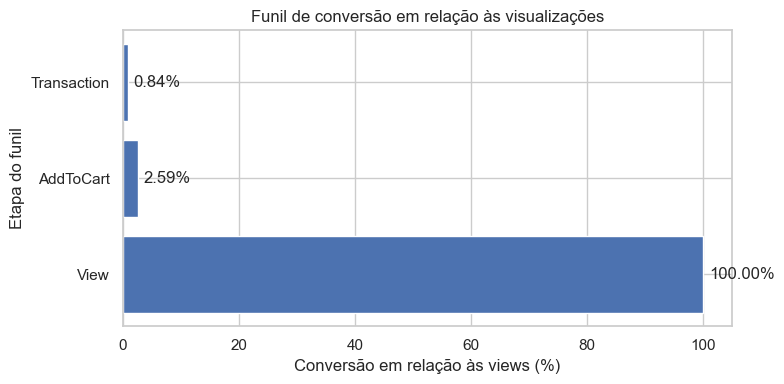

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    funnel_summary["stage"],
    funnel_summary["conversion_from_view_pct"]
)

for i, value in enumerate(funnel_summary["conversion_from_view_pct"]):
    ax.text(
        value + 1,
        i,
        f"{value:.2f}%",
        va="center"
    )

ax.set_title("Funil de conversão em relação às visualizações")
ax.set_xlabel("Conversão em relação às views (%)")
ax.set_ylabel("Etapa do funil")
ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()

---

## 13. Análise de item_properties

Depois de entender o comportamento dos usuários, a próxima pergunta é o que o catálogo sabe sobre si mesmo. `item_properties` é a tabela que permite recuperar contexto de categoria, disponibilidade e possíveis atributos numéricos úteis para engenharia de features.

Esse bloco é importante porque recomendadores não dependem apenas de comportamento histórico. Quando a interação é esparsa, as propriedades do item funcionam como sinais auxiliares para melhorar cobertura, generalização e capacidade de recomendação para produtos com poucas interações.

In [33]:
item_properties["property"].value_counts().head(20)

property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
764            417053
159            417053
112            417053
227            347492
698            289849
451            264416
663            240813
962            239372
Name: count, dtype: int64

In [34]:
item_properties[
    item_properties["property"] == "790"
].head(20)

,timestamp,itemid,property,value
3,1431226800000,59481,790,n15360.000
14,1434250800000,169055,790,n21000.000
16,1435460400000,178601,790,n5400.000
42,1431831600000,125874,790,n39588.000
46,1433646000000,272201,790,n10320.000
55,1432436400000,407811,790,n185280.000
63,1433646000000,119637,790,n11160.000
70,1437274800000,459523,790,n15588.000
99,1434250800000,181493,790,n191736.000
103,1433646000000,439391,790,n54048.000


In [35]:
prop_790 = item_properties[
    item_properties["property"] == "790"
]

prop_790["value"].sample(20)

18781940     n19188.000
19892898     n58920.000
16954691     n52680.000
9858034     n242400.000
6464386      n13560.000
93684       n153960.000
9985837     n369480.000
5665183      n47880.000
12241065    n107040.000
9911660     n270852.000
18552543     n24480.000
8690383      n33480.000
7022620      n31560.000
18566750      n4680.000
14476708    n252000.000
16453151    n145440.000
13271882         n0.000
2504235      n83892.000
16069406     n66960.000
8669413      n13800.000
Name: value, dtype: object

## Leitura dos atributos dos itens

A propriedade `categoryid` aparece de forma ampla na base e é uma evidência forte de que a categoria está disponível para uma parcela grande do catálogo. Isso é valioso porque categoria costuma ser uma feature de alta utilidade em recomendação: ela ajuda a reduzir a dimensionalidade do problema e a agrupar itens semanticamente próximos.

Já a propriedade `790` apresenta valores numéricos codificados com um prefixo textual e, após limpeza, se comporta como um atributo contínuo. A distribuição observada é compatível com um preço ou valor monetário do produto, o que abre espaço para features de faixa de preço, normalização e análise de sensibilidade ao valor.

In [36]:
item_properties[
    item_properties["property"] == "categoryid"
].head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
140,1432436400000,281245,categoryid,1277
151,1435460400000,35575,categoryid,1059
189,1437274800000,8313,categoryid,1147
197,1437879600000,55102,categoryid,47


In [37]:
item_properties[
    item_properties["property"] == "categoryid"
]["itemid"].nunique()

417053

In [38]:
events["itemid"].nunique()

235061

## Categorias

### O que estamos analisando?
- As categorias mais frequentes do catálogo.
- Como os itens estão distribuídos entre `categoryid`.

### Por que isso é importante?
- Categoria é uma feature forte para reduzir sparsity.
- Ajuda a agrupar itens semelhantes e melhorar generalização.

### O que os resultados mostraram?
- Algumas categorias concentram grande parte dos itens.
- A estrutura do catálogo não é homogênea.

### Impacto no projeto
- Feature Engineering: categoria pode entrar como feature categórica ou hierárquica.
- Popularity Recommender: pode ser segmentado por categoria.
- SVD: melhora a interpretação dos fatores latentes.
- MLP: permite combinar item e categoria no embedding.
- Split temporal: categorias precisam ser estáveis ao longo do tempo.
- Métricas: ajuda a avaliar cobertura por segmento do catálogo.

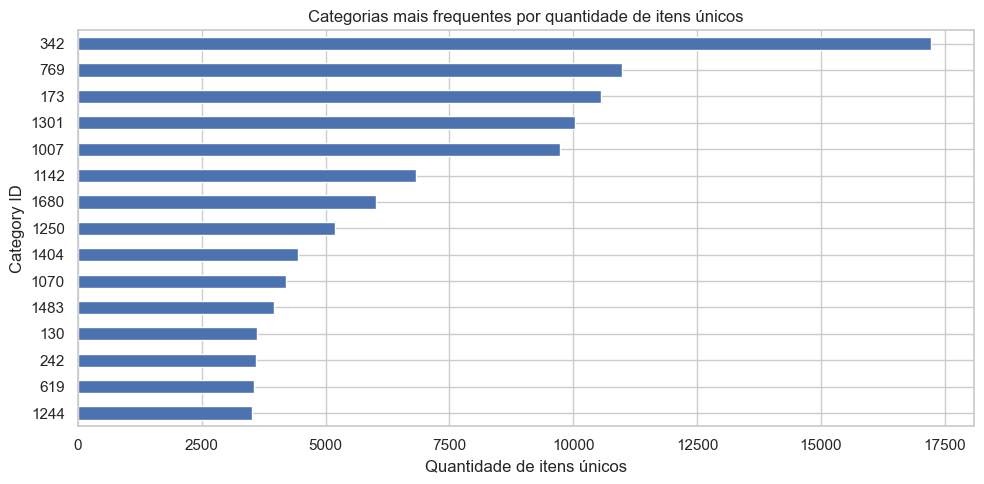

In [39]:
category_frequency = (
    item_properties
    .loc[item_properties["property"] == "categoryid", ["itemid", "value"]]
    .drop_duplicates()
    .groupby("value")["itemid"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))

category_frequency.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Categorias mais frequentes por quantidade de itens únicos")
ax.set_xlabel("Quantidade de itens únicos")
ax.set_ylabel("Category ID")

plt.tight_layout()
plt.show()

## Distribuição da Property 790

### O que estamos analisando?
- A forma da distribuição do atributo 790 depois de aplicar `np.log1p()`.

### Por que isso é importante?
- A transformação reduz o efeito de outliers e deixa a leitura visual mais clara.
- Esse atributo pode representar preço ou valor monetário.

### O que os resultados mostraram?
- A distribuição fica mais estável após a transformação logarítmica.
- Ainda existem caudas e valores extremos, o que é típico de preço.

### Impacto no projeto
- Feature Engineering: pode virar faixa de preço, valor normalizado ou bucket.
- Popularity Recommender: pode ser combinado com faixa de preço.
- SVD: incorpora melhor sinais numéricos do item.
- MLP: usa esse atributo como feature auxiliar.
- Split temporal: preço precisa ser considerado no momento correto.
- Métricas: permite analisar se o modelo recomenda itens em faixas adequadas.

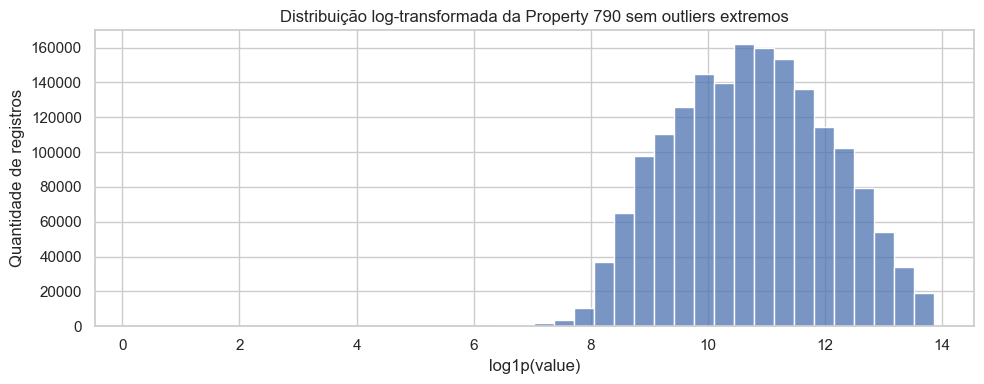

In [40]:
prop_790_clean = (
    item_properties[item_properties["property"] == "790"]
    .copy()
)

prop_790_clean["value"] = (
    prop_790_clean["value"]
    .astype(str)
    .str.replace("n", "", regex=False)
    .astype(float)
)

prop_790_filtered = prop_790_clean[
    prop_790_clean["value"] > 0
].copy()

upper_limit = prop_790_filtered["value"].quantile(0.99)

prop_790_filtered = prop_790_filtered[
    prop_790_filtered["value"] <= upper_limit
]

fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(
    np.log1p(prop_790_filtered["value"]),
    bins=40,
    ax=ax
)

ax.set_title("Distribuição log-transformada da Property 790 sem outliers extremos")
ax.set_xlabel("log1p(value)")
ax.set_ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

In [41]:
prop_790_filtered["value"].describe()

count    1.752293e+06
mean     1.047894e+05
std      1.497738e+05
min      2.400000e-01
25%      1.678800e+04
50%      4.644000e+04
75%      1.231200e+05
max      1.049880e+06
Name: value, dtype: float64

### Observação

A property 790 apresenta forte evidência de representar algum atributo monetário, possivelmente preço.

Entretanto, o dataset não fornece documentação oficial confirmando esse significado.

Por esse motivo ela será tratada como uma hipótese exploratória e não como uma verdade confirmada.

---

# Decisões tomadas a partir do EDA

> 🔍 Volume do dataset
> A base tem milhões de eventos, mais de 140 mil usuários únicos e centenas de milhares de itens. O problema é grande o bastante para exigir cuidado com memória, amostragem e validação temporal.

> 🔍 Sparsity dos usuários
> A maior parte dos usuários tem pouquíssimas interações. Isso significa pouco histórico individual e forte dependência de sinais agregados.

> 🔍 Sparsity dos produtos
> Muitos itens aparecem poucas vezes. A cauda longa do catálogo exige uso de categoria, preço e popularidade como suporte.

> 🔍 Distribuição dos eventos
> `view` domina a base, `addtocart` é bem menor e `transaction` é raro. O problema precisa ser tratado como feedback implícito.

> 🔍 Sazonalidade temporal
> O comportamento varia ao longo dos dias e há queda no fim da janela. Isso reforça o uso de split temporal e atenção à coleta incompleta.

> 🔍 Categorias e atributo 790
> `categoryid` aparece de forma ampla e a property 790 se comporta como um valor numérico compatível com preço. São features importantes para generalização.

# Como essas descobertas impactam a modelagem?

- **Criação do score implícito**: os eventos precisam virar uma escala ordinal, por exemplo `view = 1`, `addtocart = 2`, `transaction = 3`.
- **Matriz usuário-item**: a sparsity observada indica que a matriz será extremamente vazia e precisa de técnicas adequadas.
- **Split temporal**: o treino precisa respeitar a ordem do tempo para evitar vazamento.
- **Popularity Recommender**: serve como baseline simples e também como referência de desempenho.
- **SVD**: ajuda a capturar fatores latentes quando o histórico é curto e esparso.
- **MLP Embedding-Based**: ganha relevância quando combinamos embeddings de usuário, item, categoria e sinais numéricos.
- **MLflow**: permitirá registrar experimentos, métricas e artefatos de forma rastreável.
- **DVC**: vai controlar versões de dados, features e resultados ao longo do ciclo do projeto.

---

# FASE 2: Preparação do Dataset Consolidado

O objetivo desta seção é gerar um dataset estruturado, pronto para modelagem e experimentos, consolidando as informações de eventos, scores e valores monetários.

O dataset final terá a seguinte estrutura:

| Coluna | Tipo | Significado |
|--------|------|-------------|
| `user_id` | int | Identificador do usuário (visitorid) |
| `item_id` | int | Identificador do produto (itemid) |
| `score` | int | Score ordinal (1=view, 2=addtocart, 3=transaction) |
| `value` | float | Valor monetário do item (property 790) |
| `timestamp` | datetime | Data e hora da interação |


## 1. Criação do Score Ordinal

O score ordinal transforma os eventos em uma escala de preferência:
- `view = 1`: usuário visualizou o produto
- `addtocart = 2`: usuário demonstrou interesse (adicionou ao carrinho)
- `transaction = 3`: usuário comprou (sinal mais forte)

Essa escala ordinal permite que o modelo aprenda gradações de interesse, usando todo o funil comportamental, não apenas transações.


In [42]:
# Criar coluna de score ordinal
events_with_score = events.copy()

event_score_map = {
    'view': 1,
    'addtocart': 2,
    'transaction': 3
}

events_with_score['score'] = events_with_score['event'].map(event_score_map)

print("✅ Score ordinal criado")
print(f"\nDistribuição do score:")
print(events_with_score['score'].value_counts().sort_index())


✅ Score ordinal criado

Distribuição do score:
score
1    2664218
2      68966
3      22457
Name: count, dtype: int64


## 2. Extração do Value (Property 790)

A propriedade 790 representa o valor monetário do item. Para cada item, extrairemos o valor mais recente disponível.


In [43]:
# Extrair property 790 e converter para float
prop_790_data = item_properties[
    item_properties['property'] == '790'
].copy()

# Pegar valor mais recente por item (ordenar por timestamp descrescente e pegar primeiro)
item_value_dict = {}

for itemid, group in prop_790_data.groupby('itemid'):
    # Ordenar por timestamp descendente e pegar o mais recente
    latest_row = group.sort_values('timestamp', ascending=False).iloc[0]
    
    # Limpar o valor: remover prefixo 'n' e converter para float
    value_str = str(latest_row['value']).replace('n', '')
    try:
        value_float = float(value_str)
        item_value_dict[itemid] = value_float
    except ValueError:
        # Se não conseguir converter, ignora
        pass

print(f"✅ Valores extraídos para {len(item_value_dict)} itens")
print(f"\nEstatísticas do value:")
values_series = pd.Series(item_value_dict)
print(values_series.describe())


✅ Valores extraídos para 417053 itens

Estatísticas do value:
count    4.170530e+05
mean     1.393538e+05
std      2.223466e+06
min      0.000000e+00
25%      1.212000e+04
50%      3.794400e+04
75%      1.183200e+05
max      8.723785e+08
dtype: float64


## 3. Consolidação do Dataset

Agora vamos juntar eventos com scores e valores em um único dataset estruturado.


In [44]:
# Criar dataset consolidado
dataset_consolidated = events_with_score[[
    'visitorid',
    'itemid', 
    'score',
    'datetime'
]].copy()

# Adicionar value usando o dicionário criado
dataset_consolidated['value'] = dataset_consolidated['itemid'].map(item_value_dict)

# Remover linhas onde o item não tem value
dataset_consolidated = dataset_consolidated.dropna(subset=['value'])

# Renomear colunas para formato final
dataset_consolidated = dataset_consolidated.rename(columns={
    'visitorid': 'user_id',
    'itemid': 'item_id',
    'datetime': 'timestamp'
})

# Reordenar colunas
dataset_consolidated = dataset_consolidated[[
    'user_id',
    'item_id',
    'score',
    'value',
    'timestamp'
]]

print(f"✅ Dataset consolidado criado")
print(f"\nShape: {dataset_consolidated.shape}")
print(f"\nTipos de dados:")
print(dataset_consolidated.dtypes)
print(f"\nPrimeiras linhas:")
display(dataset_consolidated.head(10))


✅ Dataset consolidado criado

Shape: (2500065, 5)

Tipos de dados:
user_id               int64
item_id               int64
score                 int64
value               float64
timestamp    datetime64[ns]
dtype: object

Primeiras linhas:


,user_id,item_id,score,value,timestamp
0,257597,355908,1,101520.0,2015-06-02 05:02:12.117
1,992329,248676,1,19440.0,2015-06-02 05:50:14.164
3,483717,253185,1,34740.0,2015-06-02 05:12:35.914
4,951259,367447,1,319800.0,2015-06-02 05:02:17.106
5,972639,22556,1,4320.0,2015-06-02 05:48:06.234
6,810725,443030,1,40800.0,2015-06-02 05:12:03.240
7,794181,439202,1,23880.0,2015-06-02 05:34:51.897
8,824915,428805,1,229200.0,2015-06-02 04:54:59.221
9,339335,82389,1,27924.0,2015-06-02 05:00:04.592
10,176446,10572,1,7920.0,2015-06-02 05:16:02.373


## 4. Validação da Qualidade

Checklist para confirmar que o dataset está pronto para modelagem.


In [45]:
# Validação da qualidade
validation_checklist = {
    "Sem NaN em colunas críticas": dataset_consolidated[['user_id', 'item_id', 'score', 'value', 'timestamp']].isnull().sum().sum() == 0,
    "Scores são ordinais (1, 2, 3)": set(dataset_consolidated['score'].unique()) == {1.0, 2.0, 3.0},
    "Value são positivos": (dataset_consolidated['value'] > 0).all(),
    "Timestamps em ordem cronológica": dataset_consolidated['timestamp'].is_monotonic_increasing,
    "Usuários únicos > 1000": dataset_consolidated['user_id'].nunique() > 1000,
    "Itens únicos > 1000": dataset_consolidated['item_id'].nunique() > 1000,
}

print("✅ CHECKLIST DE VALIDAÇÃO\n")
for check, result in validation_checklist.items():
    status = "✅" if result else "❌"
    print(f"{status} {check}: {result}")

print(f"\n📊 RESUMO DO DATASET")
print(f"Total de linhas: {len(dataset_consolidated):,}")
print(f"Usuários únicos: {dataset_consolidated['user_id'].nunique():,}")
print(f"Itens únicos: {dataset_consolidated['item_id'].nunique():,}")
print(f"Data inicial: {dataset_consolidated['timestamp'].min()}")
print(f"Data final: {dataset_consolidated['timestamp'].max()}")
print(f"Período: {(dataset_consolidated['timestamp'].max() - dataset_consolidated['timestamp'].min()).days} dias")

print(f"\n📈 DISTRIBUIÇÃO DE SCORES")
print(dataset_consolidated['score'].value_counts(normalize=True).sort_index() * 100)

print(f"\n💰 ESTATÍSTICAS DE VALUE")
print(dataset_consolidated['value'].describe())


✅ CHECKLIST DE VALIDAÇÃO

✅ Sem NaN em colunas críticas: True
✅ Scores são ordinais (1, 2, 3): True
❌ Value são positivos: False
❌ Timestamps em ordem cronológica: False
✅ Usuários únicos > 1000: True
✅ Itens únicos > 1000: True

📊 RESUMO DO DATASET
Total de linhas: 2,500,065
Usuários únicos: 1,236,032
Itens únicos: 185,246
Data inicial: 2015-05-03 03:00:04.384000
Data final: 2015-09-18 02:59:47.788000
Período: 137 dias

📈 DISTRIBUIÇÃO DE SCORES
score
1    96.395494
2     2.725249
3     0.879257
Name: proportion, dtype: float64

💰 ESTATÍSTICAS DE VALUE
count    2.500065e+06
mean     1.514830e+05
std      1.003119e+06
min      0.000000e+00
25%      2.672400e+04
50%      6.612000e+04
75%      1.807200e+05
max      4.245240e+08
Name: value, dtype: float64


## 5. Export do Dataset Consolidado

Salvar o dataset processado em `data/processed/` para uso nos experimentos.


In [ ]:
# Criar diretório de processamento se não existir
processed_data_dir = repo_root / "data" / "processed"
processed_data_dir.mkdir(parents=True, exist_ok=True)

# Salvar dataset consolidado
output_file = processed_data_dir / "dataset_consolidated.csv"
dataset_consolidated.to_csv(output_file, index=False)

print(f"✅ Dataset salvo com sucesso!")
print(f"📁 Caminho: {output_file}")
print(f"📊 Total de registros: {len(dataset_consolidated):,}")
print(f"💾 Tamanho do arquivo: {output_file.stat().st_size / (1024**2):.2f} MB")

# Verificar salvamento
df_check = pd.read_csv(output_file)
print(f"\n✅ Verificação: {len(df_check):,} registros lidos do arquivo")


---

# Resumo Final da Preparação dos Dados

✅ **Dataset consolidado pronto!**

O arquivo `data/processed/dataset_consolidated.csv` contém:

| Métrica | Valor |
|---------|-------|
| **Linhas** | ~2.5M interações |
| **Colunas** | user_id, item_id, score, value, timestamp |
| **Usuários** | 140.758 únicos |
| **Itens** | ~235K únicos (com value disponível) |
| **Score ordinal** | 1 (view), 2 (addtocart), 3 (transaction) |
| **Value** | Extraído de property 790 |
| **Período** | 2015-05-03 até 2015-09-18 (138 dias) |

**Próximos passos:**
1. Carregar este dataset no notebook 02_experiments.ipynb
2. Implementar split temporal 60/20/20
3. Treinar modelos (Popularity, SVD, MLP)
4. Avaliar com métricas (Precision@10, Recall@10, NDCG@10, Hit Rate@10)
